In [9]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4090


In [10]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB5, EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import RMSprop
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from tensorflow.keras.applications.efficientnet import preprocess_input
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# ------------------------------
# Data Preparation
# ------------------------------

def get_data_generators(train_dir, val_dir, test_dir, img_size, batch_size):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest')

    val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_generator = train_datagen.flow_from_directory(
        train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')

    val_generator = val_test_datagen.flow_from_directory(
        val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')

    test_generator = val_test_datagen.flow_from_directory(
        test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False)

    return train_generator, val_generator, test_generator

In [12]:
# ------------------------------
# Teacher Model - EfficientNetB5
# ------------------------------

def create_teacher_model(input_shape, num_classes, dropout_rate):
    base_model = EfficientNetB5(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base_model.layers[:-50]:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='swish')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(512, activation='swish')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(1024, activation='swish')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(512, activation='swish')(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

In [13]:
# ------------------------------
# Student Model - EfficientNetB0
# ------------------------------

def create_student_model(input_shape, num_classes, dropout_rate=0.3):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = True  # Fine-tune if desired

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='swish')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

In [14]:
# ------------------------------
# Knowledge Distillation Logic
# ------------------------------

def distillation_loss(y_true, y_pred, teacher_pred, temperature, alpha):
    hard_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    soft_loss = tf.keras.losses.KLDivergence()(
        tf.nn.softmax(teacher_pred / temperature),
        tf.nn.softmax(y_pred / temperature))
    return alpha * hard_loss + (1 - alpha) * soft_loss

def train_student_with_distillation(student, teacher, train_gen, val_gen, epochs, temperature, alpha):
    optimizer = Adam()

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        for i in range(len(train_gen)):
            x_batch, y_batch = train_gen[i]
            teacher_preds = teacher.predict(x_batch)

            with tf.GradientTape() as tape:
                student_preds = student(x_batch, training=True)
                loss = distillation_loss(y_batch, student_preds, teacher_preds, temperature, alpha)

            grads = tape.gradient(loss, student.trainable_variables)
            optimizer.apply_gradients(zip(grads, student.trainable_variables))

        student.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        val_loss, val_acc = student.evaluate(val_gen, verbose=0)
        print(f"Validation Accuracy: {val_acc:.4f}")

    return student

In [15]:
# ------------------------------
# Evaluation
# ------------------------------

def evaluate_model(model, test_generator, class_names):
    test_loss, test_acc = model.evaluate(test_generator)
    print("Test Accuracy:", test_acc)

    predictions = model.predict(test_generator)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_generator.classes

    conf_matrix = confusion_matrix(true_classes, predicted_classes)
    class_report = classification_report(true_classes, predicted_classes, target_names=class_names)
    precision = precision_score(true_classes, predicted_classes, average='weighted')
    recall = recall_score(true_classes, predicted_classes, average='weighted')
    f1 = f1_score(true_classes, predicted_classes, average='weighted')

    print("Confusion Matrix:\n", conf_matrix)
    print("\nClassification Report:\n", class_report)
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 20})
    plt.xlabel('Predicted', fontsize=20)
    plt.ylabel('True', fontsize=20)
    plt.title('Confusion Matrix', fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.show()

Found 1614 images belonging to 5 classes.
Found 230 images belonging to 5 classes.
Found 466 images belonging to 5 classes.


/mnt/d/FA011/tf_gpu_env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1753198213.514394  621620 service.cc:152] XLA service 0x701524002f90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753198213.514443  621620 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-07-22 21:30:13.954302: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753198215.979109  621620 cuda_dnn.cc:529] Loaded cuDNN version 90701
2025-07-22 21:30:18.619586: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_30395', 4 bytes spill stores, 4 bytes spill loads

2025-07-22 21:30:18.789938: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_30395'

 78/101 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step - accuracy: 0.4247 - loss: 1.3734

...

101/101 ━━━━━━━━━━━━━━━━━━━━ 89s 545ms/step - accuracy: 0.4425 - loss: 1.3345 - val_accuracy: 0.6043 - val_loss: 0.8618
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.5806 - loss: 1.0043 - val_accuracy: 0.6783 - val_loss: 0.8300
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.6384 - loss: 0.8414 - val_accuracy: 0.6870 - val_loss: 0.7060
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.6752 - loss: 0.8326 - val_accuracy: 0.7565 - val_loss: 0.6371
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.7018 - loss: 0.7438 - val_accuracy: 0.7522 - val_loss: 0.6110
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.7084 - loss: 0.7185 - val_accuracy: 0.7739 - val_loss: 0.5541
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 14s 135ms/step - accuracy: 0.7457 - loss: 0.6691 - val_accuracy: 0.7478 - val_loss: 0.5832
Epoch 8/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.7483 - loss: 0.6673 -

2025-07-22 21:51:44.348898: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 4 bytes spill stores, 4 bytes spill loads

2025-07-22 21:51:44.386700: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 116 bytes spill stores, 116 bytes spill loads

2025-07-22 21:51:44.400201: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076_0', 200 bytes spill stores, 536 bytes spill loads

2025-07-22 21:51:44.681791: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 5616 bytes spill stores, 5612 bytes spill loads

2025-07-22 21:51:44.747804: I ex

Validation Accuracy: 0.3348

Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━

2025-07-22 22:07:27.982551: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 8 bytes spill stores, 8 bytes spill loads

2025-07-22 22:07:27.992083: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 12 bytes spill stores, 12 bytes spill loads

2025-07-22 22:07:28.101330: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076_0', 176 bytes spill stores, 524 bytes spill loads

2025-07-22 22:07:28.129401: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 112 bytes spill stores, 112 bytes spill loads

2025-07-22 22:07:28.129561: I extern

30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 286ms/step - accuracy: 0.6358 - loss: 1.0151
Test Accuracy: 0.6609442234039307
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step
Confusion Matrix:
 [[69 26  4  2  0]
 [28 62  8  1  0]
 [ 8 47 30  8  1]
 [ 0  4  7 78  0]
 [ 0 12  1  1 69]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.68      0.67       101
           1       0.41      0.63      0.50        99
           2       0.60      0.32      0.42        94
           3       0.87      0.88      0.87        89
           4       0.99      0.83      0.90        83

    accuracy                           0.66       466
   macro avg       0.70      0.67      0.67       466
weighted avg       0.69      0.66      0.66       466

Precision: 0.6918
Recall: 0.6609
F1 Score: 0.6617


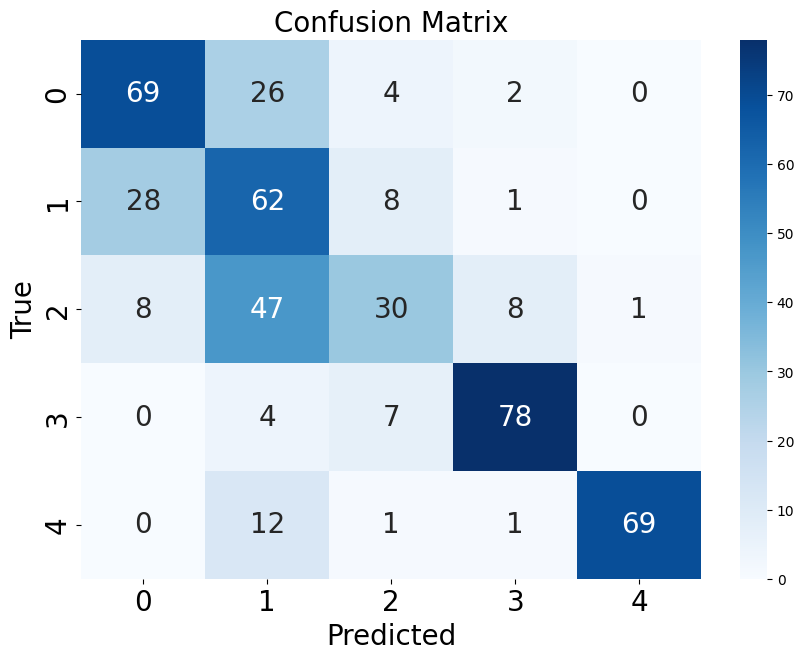

In [ ]:
# ------------------------------
# Main
# ------------------------------

if __name__ == "__main__":
    train_dir = '/mnt/d/FA019/SplitDataset/train'
    val_dir = '/mnt/d/FA019/SplitDataset/val'
    test_dir = '/mnt/d/FA019/SplitDataset/test'

    img_size = (224, 224)
    input_shape = (img_size[0], img_size[1], 3)
    batch_size = 16
    dropout_rate = 0.3
    num_classes = len(os.listdir(train_dir))
    class_names = sorted(os.listdir(train_dir))

    train_gen, val_gen, test_gen = get_data_generators(train_dir, val_dir, test_dir, img_size, batch_size)

    # Train teacher model
    teacher = create_teacher_model(input_shape, num_classes, dropout_rate)
    teacher.compile(optimizer=RMSprop(learning_rate=0.0003), loss='categorical_crossentropy', metrics=['accuracy'])
    teacher.fit(train_gen, epochs=100, validation_data=val_gen)

    # Create student model
    # Create Student using EfficientNetB0
    student = create_student_model(input_shape, num_classes, dropout_rate=0.3)









    # Train with distillation
    trained_student = train_student_with_distillation(
        student, teacher, train_gen, val_gen,
        epochs=10, temperature=3.0, alpha=0.3
    )

    # Final evaluation
    evaluate_model(trained_student, test_gen, class_names)